In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import linregress
import numpy as np

In [4]:
def plot_csv_data(file_path, x_col, y_col):
    # 1. Read the CSV file
    df = pd.read_csv(file_path)
    
    # 2. Extract the data
    x = df[x_col]
    y = df[y_col]
    
    r_value, p_value = pearsonr(x,y)
    rho, p_value2 = spearmanr(x, y)
    print(f"Pearson correlation coefficient: {r_value}, p-value: {p_value}")
    print(f"Spearman correlation coefficient: {rho}, p-value: {p_value2}")
    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, marker='o', color='b')
    
    # 4. Add labels and title
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Plot of {y_col} vs {x_col}')
    plt.grid(True)
    
    # 5. Show the plot
    plt.show()

Pearson correlation coefficient: -0.5362784258634341, p-value: 5.89644634989917e-06
Spearman correlation coefficient: -0.5027062709528816, p-value: 2.6857720636664627e-05


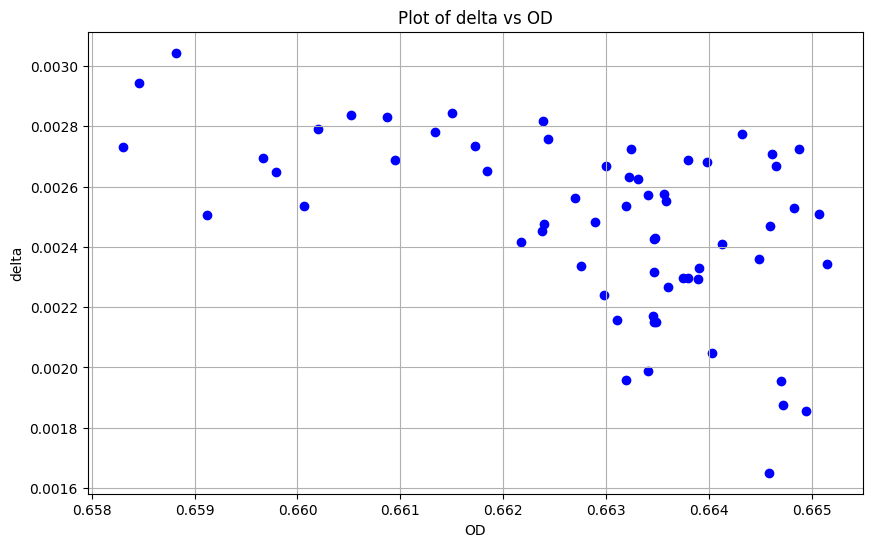

In [5]:
plot_csv_data("data/od_delta_500cGy_1st_set.csv",'OD','delta')

2.21.26:  slope = 4.30e-05 OD/min,  R^2 = 0.8,  p = 0.0000
2.23.26:  slope = 4.73e-05 OD/min,  R^2 = 0.5,  p = 0.0000


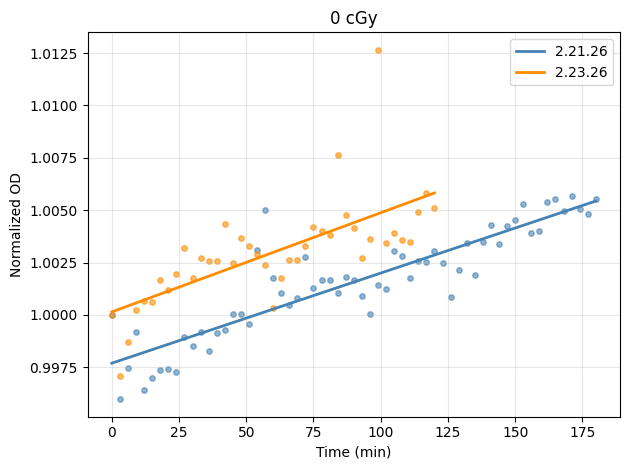

2.23.26:  slope = 5.33e-05 OD/min,  R^2 = 0.8,  p = 0.0000
2.25.26:  slope = 2.46e-05 OD/min,  R^2 = 0.3,  p = 0.0000


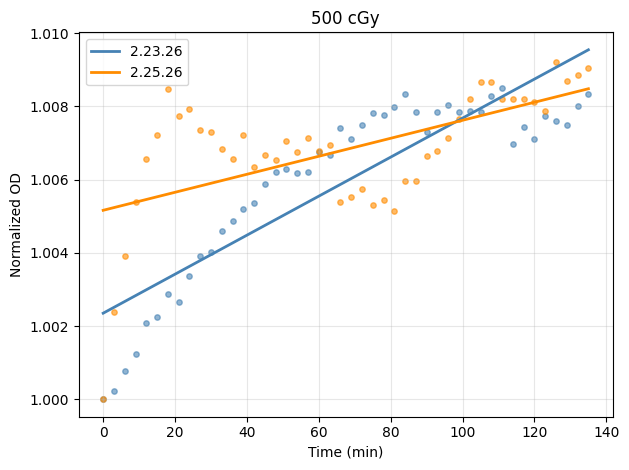

In [ ]:
def plot_normalized_od(file_path, title=None):                                                                                                          
    df = pd.read_csv(file_path)                                                                                                              
    t = df.iloc[:, 0]                                                                                                                        
    colors = ['steelblue', 'darkorange', 'green', 'red']

    for col, c in zip(df.columns[1:], colors):
        y = df[col].dropna()
        t_sub = t[:len(y)]
        slope, intercept, r, p, _ = linregress(t_sub, y)
        plt.scatter(t_sub, y, s=15, color=c, alpha=0.6)
        plt.plot(t_sub, slope * t_sub + intercept, '-', color=c, lw=2, label=col)
        print(f"{col}:  slope = {slope:.2e} OD/min,  R^2 = {r**2:.3f},  p = {p:.4f}")

    plt.xlabel('Time (min)')
    plt.ylabel('Normalized OD')
    plt.title(title or file_path)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_normalized_od('data/normalized_data_0cGy.csv', '0 cGy')
plot_normalized_od('data/normalized_data_500cGy.csv', '500 cGy')